In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from tool import *
seed_all(42)
DEV = device()
print(DEV)

cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 499kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.68MB/s]


torch.Size([3000, 1, 28, 28]) torch.Size([3000]) torch.Size([500, 1, 28, 28]) torch.Size([500])


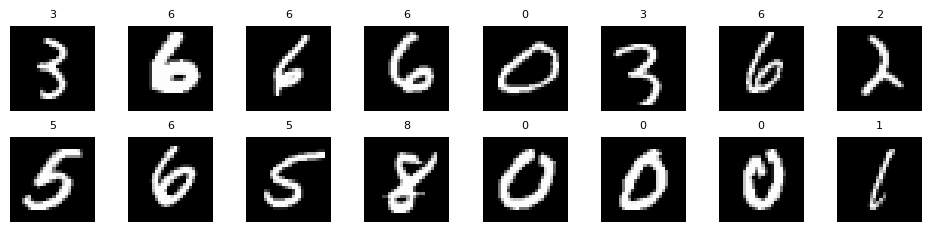

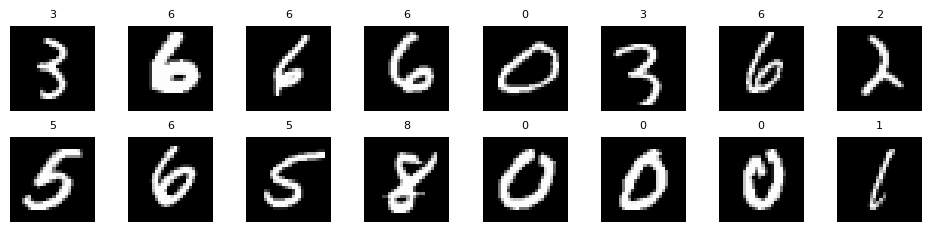

In [3]:
Xtr, ytr, Xte, yte = load_mnist_small(n_train=3000, n_test=500)
print(Xtr.shape, ytr.shape, Xte.shape, yte.shape)
show_images(Xtr[:16], titles=ytr[:16].tolist(), cols=8)

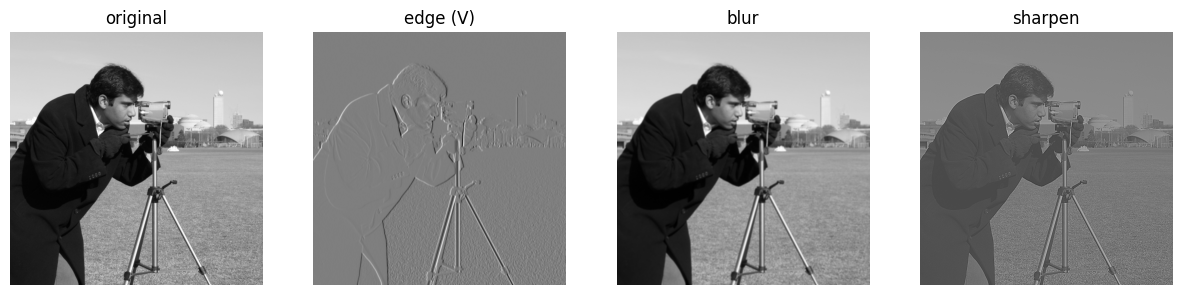

In [4]:
import numpy as np
from skimage import data
from scipy.ndimage import convolve

photo = data.camera().astype(np.float32) / 255.0

kernels = {
    'original': np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]]),
    'edge (V)': np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]]),
    'blur': np.ones((3, 3)) / 9,
    'sharpen': np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
}

fig, axes = plt.subplots(1, len(kernels), figsize=(15, 4))
for ax, (name, K) in zip(axes, kernels.items()):
    filtered = convolve(photo, K)
    ax.imshow(filtered, cmap='gray')
    ax.set_title(name)
    ax.axis('off')

In [5]:
class MLP(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden), 
            nn.ReLU(),
            nn.Linear(hidden, 10)
        )

    def forward(self, x):
        return self.net(x)
    
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features  = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(32*7*7, 10))
    def forward(self, x):
        return self.head(self.features(x))
    
mlp = MLP().to(DEV)
cnn = CNN().to(DEV)
count_params(mlp), count_params(cnn)

(118282, 20490)

In [6]:
EPOCHS = 10

hist_mlp, t_mlp, mem_mlp = benchmark(train_classifier, mlp, Xtr, ytr, epochs=EPOCHS, lr=1e-3, verbose=False)
print(f'MLP trained in {t_mlp:.2f}s, {mem_mlp:.2f}GB, acc={hist_mlp[-1]:.4f}')

MLP trained in 1.53s, 19.78GB, acc=0.0946


In [7]:
hist_cnn, t_cnn, mem_cnn = benchmark(train_classifier, cnn, Xtr, ytr, epochs=EPOCHS, lr=1e-3, verbose=False)
print(f'CNN trained in {t_cnn:.2f}s, {mem_cnn:.2f}GB, acc={hist_cnn[-1]:.4f}')

CNN trained in 1.73s, 33.13GB, acc=0.0824


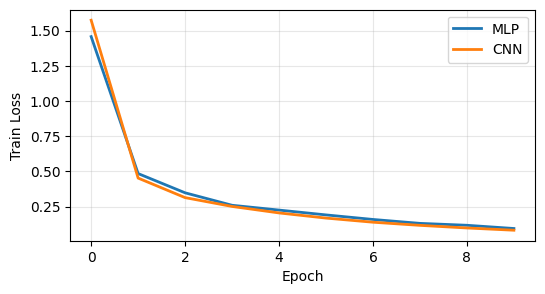

In [8]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(hist_mlp, label='MLP', lw=2)
ax.plot(hist_cnn, label='CNN', lw=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Train Loss')
ax.legend()
ax.grid(alpha=0.3)

In [9]:
acc_mlp = accuracy(mlp, Xte, yte)
acc_cnn = accuracy(cnn, Xte, yte)
print(f'MLP test acc: {acc_mlp:.4f}')
print(f'CNN test acc: {acc_cnn:.4f}')

MLP test acc: 0.9340
CNN test acc: 0.9580
